
# **IT3012 WEEK 7 Practical**

## Fuzzy Inference Systems

In this practical, you will construct and evaluate a fuzzy controller for an autonomous cleaning robot.

The system takes environmental sensor inputs (dirt level and surface type) and determines appropriate cleaning behaviour (intensity and duration). Through this exercise, you will explore how fuzzy rules combine to produce adaptive decisions in uncertain environments.


By the end of this session, you will have built a complete fuzzy logic controller that:
- takes sensor inputs (dirt level, surface type)
- makes intelligent decisions (cleaning intensity, cleaning duration)
- handles competing objectives (gentle vs effective cleaning)
- behaves like a human expert would

### Setup: Import Libraries

First, let's set up our environment with the same `skfuzzy` tools from Week 5.



In [1]:
!pip install scikit-fuzzy -q


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\LapMart\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


> May need to restart the session

In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

print(f"✓ scikit-fuzzy version: {fuzz.__version__}")
print(f"✓ NumPy version: {np.__version__}")
print("✓ Ready to build fuzzy inference systems!")

✓ scikit-fuzzy version: 0.5.0
✓ NumPy version: 2.2.6
✓ Ready to build fuzzy inference systems!


### [Activity 1] Building the Fuzzy Inference System

A complete fuzzy inference system has several components:

```
1. INPUTS (Antecedents) (week 5)
   ↓
2. FUZZIFICATION (convert crisp input to fuzzy) (week 5)
   ↓
3. RULE BASE (IF-THEN rules)
   ↓
4. INFERENCE ENGINE (combine rules)
   ↓
5. AGGREGATION (merge all outputs)
   ↓
6. DEFUZZIFICATION (convert fuzzy output to crisp)
   ↓
7. OUTPUTS (Consequents)
```

Let's build this step by step using scikit-fuzzy's `control` module!


Step 1.1: Define the Input and Output Variables (Code are given)

In scikit-fuzzy, we use:
- `ctrl.Antecedent()` for inputs
- `ctrl.Consequent()` for outputs

These are more powerful than the basic fuzzy sets from Week 5 - they're designed specifically for control systems.

In [3]:
# Define the universe of discourse for each variable
# These are the possible values each variable can take

# INPUT 1: Dirt Level (0% to 100%)
dirt_level = ctrl.Antecedent(np.arange(0, 101, 1), 'dirt_level')

# INPUT 2: Surface Type (0 = delicate, 100 = hard floor)
surface_type = ctrl.Antecedent(np.arange(0, 101, 1), 'surface_type')

# OUTPUT 1: Cleaning Intensity (0% to 100%)
cleaning_intensity = ctrl.Consequent(np.arange(0, 101, 1), 'cleaning_intensity')

# OUTPUT 2: Cleaning Duration (0% to 100%)
cleaning_duration = ctrl.Consequent(np.arange(0, 101, 1), 'cleaning_duration')

print("✓ Variables defined!")
print(f"  Inputs: {dirt_level.label}, {surface_type.label}")
print(f"  Outputs: {cleaning_intensity.label}, {cleaning_duration.label}")

✓ Variables defined!
  Inputs: dirt_level, surface_type
  Outputs: cleaning_intensity, cleaning_duration


TODO

Step 1.2: Define Membership Functions. You are required to add membership functions to each variable:

* 1. DIRT LEVEL membership functions [low, medium, high] (Keep the design philosophy from Week 5.)
- 2. SURFACE TYPE membership functions [delicate, carpet, hard_floor] (Keep the design philosophy from Week 5.)
- 3. CLEANING INTENSITY membership functions [gentle, normal, aggressive] (New from this week 6)
- 4. CLEANING DURATION membership functions [quick, standard, extended] (New from this week 6)

In [4]:
# Step 1.2: Membership functions
# Shoulders (trapmf) at both ends so extreme values get full membership,
# a triangle (trimf) in the middle, and 50% overlap between neighbours.

# 1. DIRT LEVEL
dirt_level['low']    = fuzz.trapmf(dirt_level.universe, [0, 0, 20, 40])
dirt_level['medium'] = fuzz.trimf(dirt_level.universe, [25, 50, 75])
dirt_level['high']   = fuzz.trapmf(dirt_level.universe, [60, 80, 100, 100])

# 2. SURFACE TYPE (0 = delicate, 100 = hard floor)
surface_type['delicate']   = fuzz.trapmf(surface_type.universe, [0, 0, 15, 35])
surface_type['carpet']     = fuzz.trimf(surface_type.universe, [25, 50, 75])
surface_type['hard_floor'] = fuzz.trapmf(surface_type.universe, [65, 85, 100, 100])

# 3. CLEANING INTENSITY
cleaning_intensity['gentle']     = fuzz.trimf(cleaning_intensity.universe, [0, 0, 45])
cleaning_intensity['normal']     = fuzz.trimf(cleaning_intensity.universe, [25, 50, 75])
cleaning_intensity['aggressive'] = fuzz.trimf(cleaning_intensity.universe, [55, 100, 100])

# 4. CLEANING DURATION
cleaning_duration['quick']    = fuzz.trimf(cleaning_duration.universe, [0, 0, 45])
cleaning_duration['standard'] = fuzz.trimf(cleaning_duration.universe, [25, 50, 75])
cleaning_duration['extended'] = fuzz.trimf(cleaning_duration.universe, [55, 100, 100])

print("✓ Membership functions defined!")

✓ Membership functions defined!


Step 1.3: Execute the given code to visualise the membership functions. Observe the shape and overlap of the fuzzy sets, and explain how your design reflects the linguistic descriptions of the variables.

C:\Users\LapMart\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


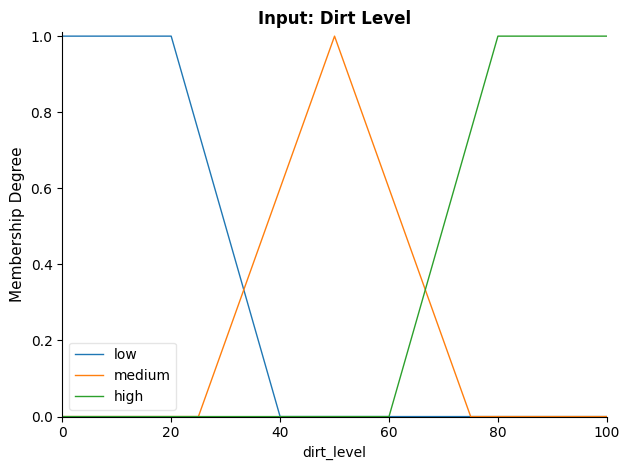

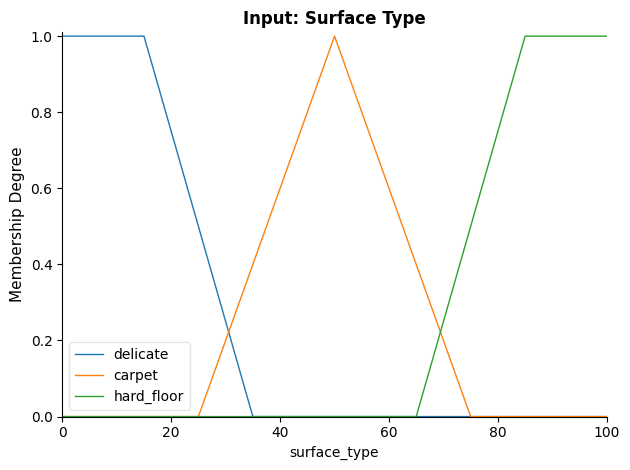

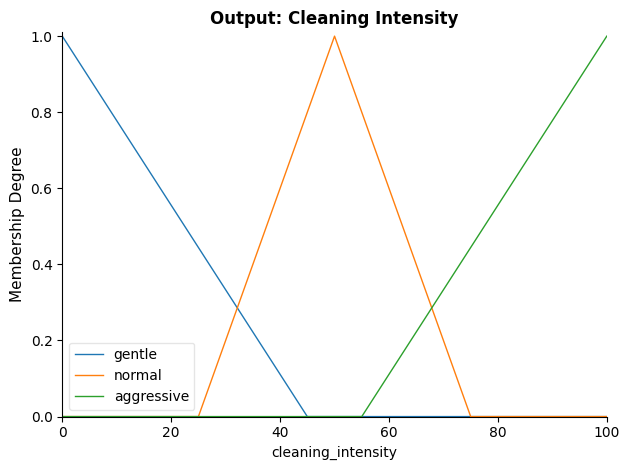

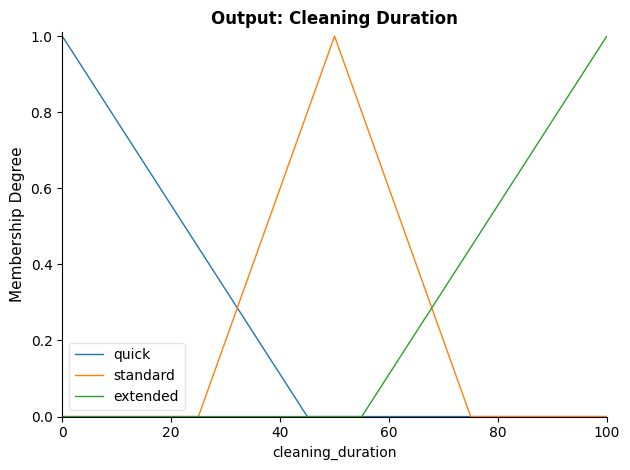

In [5]:
# Visualise all membership functions

# Figure 1: Input - Dirt Level
dirt_level.view()
plt.title('Input: Dirt Level', fontweight='bold', fontsize=12)
plt.ylabel('Membership Degree', fontsize=11)
plt.tight_layout()
plt.show()

# Figure 2: Input - Surface Type
surface_type.view()
plt.title('Input: Surface Type', fontweight='bold', fontsize=12)
plt.ylabel('Membership Degree', fontsize=11)
plt.tight_layout()
plt.show()

# Figure 3: Output - Cleaning Intensity
cleaning_intensity.view()
plt.title('Output: Cleaning Intensity', fontweight='bold', fontsize=12)
plt.ylabel('Membership Degree', fontsize=11)
plt.tight_layout()
plt.show()

# Figure 4: Output - Cleaning Duration
cleaning_duration.view()
plt.title('Output: Cleaning Duration', fontweight='bold', fontsize=12)
plt.ylabel('Membership Degree', fontsize=11)
plt.tight_layout()
plt.show()


### Answer: Step 1.3 Membership Function Design

**1. Shape choice.** The inputs (dirt level, surface type) use trapezoids at both ends, and the outputs use corner triangles at both ends. Every variable has a triangle in the middle. The end shapes give full membership (1.0) to extreme values, so 0% dirt is completely "low" and 100% dirt is completely "high". The middle triangle peaks at exactly 50, which is the most typical "medium", "carpet", "normal" or "standard" value.

**2. Overlap.** Neighbouring sets overlap (for example dirt "low" ends at 40 while "medium" starts at 25). Inside an overlap a value belongs partly to both sets. For example, dirt = 30 is 0.5 low and 0.2 medium. This matches how people speak: 30% dirt is "fairly clean but slightly dirty", not strictly one or the other.

**3. Link to the linguistic terms.**
1. Dirt level: low, medium and high are spread evenly across 0 to 100, keeping the Week 5 design.
2. Surface type: the delicate set has full membership only up to 15, so only truly fragile surfaces get the strongest protection. Hard floor is fully active from 85 upwards.
3. Cleaning intensity and duration: gentle/quick, normal/standard and aggressive/extended cover the low, middle and high parts of the output range, so the defuzzified value can land anywhere from about 15% to 85%.

**4. Coverage.** Every point of every universe has membership above zero in at least one set, so no input falls into a "gap" where no rule fires.

TODO

Step 1.4: With 2 inputs (dirt: 3 levels, surface: 3 types), we have **3 × 3 = 9 possible combinations**. For each cell, decide what cleaning intensity makes sense. (We discussed it in Lecture, you may use the discussed outcome, or you can re-design it)

Sample Rule Matrix - Layout, CLEANING INTENSITY
| Dirt \ Surface | Delicate | Carpet  | Hard Floor  |
|----------------|----------|---------|-------------|
| **Low**        | ?        | ?       | ?           |
| **Medium**     | ?        | ?       | ?           |
| **High**       | ?        | ?       | ?           |


### Answer: Step 1.4 Rule Matrices

**Cleaning Intensity**

<table><tr><th>Dirt \ Surface</th><th>Delicate</th><th>Carpet</th><th>Hard Floor</th></tr><tr><td><b>Low</b></td><td>Gentle</td><td>Gentle</td><td>Normal</td></tr><tr><td><b>Medium</b></td><td>Gentle</td><td>Normal</td><td>Aggressive</td></tr><tr><td><b>High</b></td><td>Normal</td><td>Aggressive</td><td>Aggressive</td></tr></table>

**Cleaning Duration**

<table><tr><th>Dirt \ Surface</th><th>Delicate</th><th>Carpet</th><th>Hard Floor</th></tr><tr><td><b>Low</b></td><td>Quick</td><td>Quick</td><td>Quick</td></tr><tr><td><b>Medium</b></td><td>Extended</td><td>Standard</td><td>Standard</td></tr><tr><td><b>High</b></td><td>Extended</td><td>Extended</td><td>Standard</td></tr></table>

**Design reasoning**
1. Intensity rises as dirt increases and as the surface becomes tougher. A delicate surface never gets aggressive cleaning, even at high dirt, so it is not damaged.
2. Duration is the compensating output. When intensity has to stay low on a delicate surface, the robot cleans for longer (extended), so the job still gets done.
3. A hard floor with high dirt is cleaned aggressively, so a standard duration is enough.


The rule base represents expert knowledge about how the cleaning robot should behave in different situations.

Each rule links environmental conditions (dirt level and surface type) to appropriate cleaning actions. When multiple rules are activated simultaneously, the fuzzy inference system combines their effects to determine the final output behaviour.

TODO

Step 1.5: Implementing all the Rules based on your Rule Matrix into code.



```
# Given the implementation of row 1:
# Row 1: Low Dirt
rule1 = ctrl.Rule(dirt_level['low'] & surface_type['delicate'], cleaning_intensity['gentle'])
rule2 = ctrl.Rule(dirt_level['low'] & surface_type['carpet'], cleaning_intensity['gentle'])
rule3 = ctrl.Rule(dirt_level['low'] & surface_type['hard_floor'], cleaning_intensity['normal'])
```



In [6]:
# Step 1.5: Rule base

# ---- Cleaning Intensity (rules 1 to 9) ----
# Row 1: Low Dirt
rule1 = ctrl.Rule(dirt_level['low'] & surface_type['delicate'], cleaning_intensity['gentle'])
rule2 = ctrl.Rule(dirt_level['low'] & surface_type['carpet'], cleaning_intensity['gentle'])
rule3 = ctrl.Rule(dirt_level['low'] & surface_type['hard_floor'], cleaning_intensity['normal'])
# Row 2: Medium Dirt
rule4 = ctrl.Rule(dirt_level['medium'] & surface_type['delicate'], cleaning_intensity['gentle'])
rule5 = ctrl.Rule(dirt_level['medium'] & surface_type['carpet'], cleaning_intensity['normal'])
rule6 = ctrl.Rule(dirt_level['medium'] & surface_type['hard_floor'], cleaning_intensity['aggressive'])
# Row 3: High Dirt
rule7 = ctrl.Rule(dirt_level['high'] & surface_type['delicate'], cleaning_intensity['normal'])
rule8 = ctrl.Rule(dirt_level['high'] & surface_type['carpet'], cleaning_intensity['aggressive'])
rule9 = ctrl.Rule(dirt_level['high'] & surface_type['hard_floor'], cleaning_intensity['aggressive'])

# ---- Cleaning Duration (rules 10 to 18) ----
# Delicate surfaces get extra time to make up for the gentler intensity.
# Row 1: Low Dirt
rule10 = ctrl.Rule(dirt_level['low'] & surface_type['delicate'], cleaning_duration['quick'])
rule11 = ctrl.Rule(dirt_level['low'] & surface_type['carpet'], cleaning_duration['quick'])
rule12 = ctrl.Rule(dirt_level['low'] & surface_type['hard_floor'], cleaning_duration['quick'])
# Row 2: Medium Dirt
rule13 = ctrl.Rule(dirt_level['medium'] & surface_type['delicate'], cleaning_duration['extended'])
rule14 = ctrl.Rule(dirt_level['medium'] & surface_type['carpet'], cleaning_duration['standard'])
rule15 = ctrl.Rule(dirt_level['medium'] & surface_type['hard_floor'], cleaning_duration['standard'])
# Row 3: High Dirt
rule16 = ctrl.Rule(dirt_level['high'] & surface_type['delicate'], cleaning_duration['extended'])
rule17 = ctrl.Rule(dirt_level['high'] & surface_type['carpet'], cleaning_duration['extended'])
rule18 = ctrl.Rule(dirt_level['high'] & surface_type['hard_floor'], cleaning_duration['standard'])

print("✓ 18 rules defined (9 intensity + 9 duration)")

✓ 18 rules defined (9 intensity + 9 duration)


TODO

Step 1.6: Execute the given code to create the control systems. Now we combine our rules into control systems. We'll create two separate systems since we have two outputs.

In [7]:
# Control System for Cleaning Intensity
intensity_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3,
    rule4, rule5, rule6,
    rule7, rule8, rule9
])

# Control System for Cleaning Duration
duration_ctrl = ctrl.ControlSystem([
    rule10, rule11, rule12,
    rule13, rule14, rule15,
    rule16, rule17, rule18
])

# Create simulation objects
intensity_sim = ctrl.ControlSystemSimulation(intensity_ctrl)
duration_sim = ctrl.ControlSystemSimulation(duration_ctrl)

### [Activity 2] Testing the Fuzzy Inference System

Let's see our fuzzy controller in action!

The commands `intensity_sim.compute()` and `duration_sim.compute()` run the fuzzy inference process

They perform steps automatically:
* fuzzification
* activates the fuzzy rules
* aggregation
* defuzzification

The resulting crisp value can then be accessed using commands:
* `intensity_sim.output['cleaning_intensity']`
* `duration_sim.output['cleaning_duration']`


TODO

Task 2.1: Execute the given code and identify the Centroid value. Then address the following questions.

* 1. What does the centroid value represent in the fuzzy inference system output?
* 2. How do the overlapping membership functions (gentle, normal, aggressive) influence the final centroid value?
* 3. If the input values (dirt_level or surface_type) change, how would you expect the centroid output to change? Explain your reasoning.

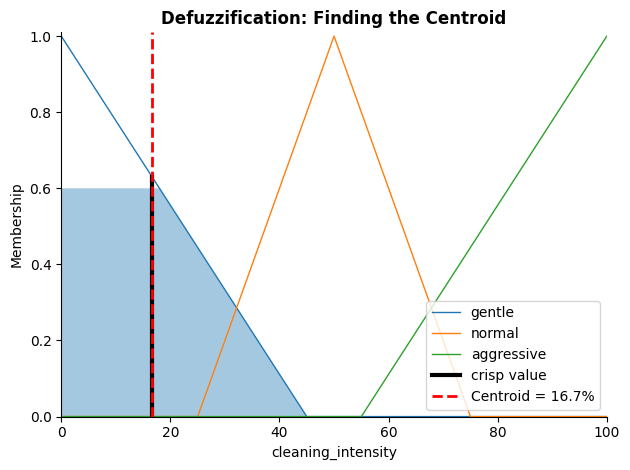

In [8]:
# Demonstrating the defuzzification process visually

# Set up the inputs
intensity_sim.input['dirt_level'] = 60
intensity_sim.input['surface_type'] = 20

# Compute
intensity_sim.compute()

# View the aggregated output and defuzzification
cleaning_intensity.view(sim=intensity_sim)
plt.title('Defuzzification: Finding the Centroid', fontweight='bold')
plt.axvline(x=intensity_sim.output['cleaning_intensity'],
            color='red', linestyle='--', linewidth=2,
            label=f"Centroid = {intensity_sim.output['cleaning_intensity']:.1f}%")
plt.legend()
plt.tight_layout()
plt.show()


### Answer: Task 2.1 Centroid

**Result:** For dirt = 60 and surface = 20, the centroid is **about 16.7%** cleaning intensity.

At these inputs, dirt is 0.6 "medium" (and 0 "high"), and surface is 0.75 "delicate". Only Rule 4 (medium dirt AND delicate surface THEN gentle) fires, with strength min(0.6, 0.75) = 0.6. The "gentle" set is clipped at 0.6 and its centre of gravity is about 16.7.

**1. What the centroid represents.** It is the crisp output of the whole system. After all fired rules are clipped and aggregated into one fuzzy shape, the centroid method finds the balance point (centre of area) of that shape. This single number is the cleaning intensity the robot actually uses.

**2. Effect of overlapping output sets.** When several rules fire, their clipped output sets (gentle, normal, aggressive) are combined with the max operator. Because the sets overlap, the combined shape is continuous, and the centroid is pulled towards whichever set has the largest clipped area. For example, if "gentle" fires at 0.6 and "normal" at 0.4, the centroid lies between the two, closer to gentle. The overlap lets the output blend smoothly instead of jumping between three fixed values.

**3. Effect of changing the inputs.** Raising the dirt level, or moving the surface towards hard floor, weakens the gentle rules and strengthens the normal and aggressive rules. The centroid then moves gradually to the right (higher intensity). Lowering either input moves it to the left. Because membership degrees change continuously, the centroid also changes gradually, not in sudden steps.

TODO

Task 2.2: Conduct a test for the following scenario:

```
Test 1: The Delicate Dilemma
Scenario: Laboratory with sensitive equipment

- Dirt Level: 80% (very dirty!)
- Surface Type: 10 (very delicate)
```

You are given a sample code to configure the test case for `Test 1: The Delicate Dilemma`. Study the code sample, execute it, and explain the fuzzy behaviour.




In [9]:
# Test Case 1: High dirt, delicate surface
test_dirt = 80
test_surface = 10

# Set inputs for intensity system
intensity_sim.input['dirt_level'] = test_dirt
intensity_sim.input['surface_type'] = test_surface

# Set inputs for duration system
duration_sim.input['dirt_level'] = test_dirt
duration_sim.input['surface_type'] = test_surface

# Compute the results
intensity_sim.compute()
duration_sim.compute()

# Get the outputs
result_intensity = intensity_sim.output['cleaning_intensity']
result_duration = duration_sim.output['cleaning_duration']

print("="*60)
print("TEST 1: Laboratory - High Dirt, Delicate Surface")
print("="*60)
print(f"\nInputs:")
print(f"  Dirt Level: {test_dirt}%")
print(f"  Surface Type: {test_surface} (very delicate)")
print(f"\nOutputs:")
print(f"  Cleaning Intensity: {result_intensity:.1f}%")
print(f"  Cleaning Duration: {result_duration:.1f}%")

TEST 1: Laboratory - High Dirt, Delicate Surface

Inputs:
  Dirt Level: 80%
  Surface Type: 10 (very delicate)

Outputs:
  Cleaning Intensity: 50.0%
  Cleaning Duration: 85.0%


### Answer: Task 2.2 The Delicate Dilemma

**Result:** Cleaning Intensity = **50.0%**, Cleaning Duration = **85.0%**

**Explanation of the fuzzy behaviour**
1. Fuzzification: dirt = 80 is fully "high" (1.0) and surface = 10 is fully "delicate" (1.0). All other memberships are 0.
2. Rule activation: only Rule 7 (high AND delicate THEN normal intensity) and Rule 16 (high AND delicate THEN extended duration) fire, both at strength 1.0.
3. Defuzzification: the full "normal" set gives a centroid of 50%, and the full "extended" set gives a centroid of about 85%.

**Interpretation.** The system faces two competing goals. The area is very dirty, which calls for aggressive cleaning, but the surface is fragile, which calls for gentle cleaning. It settles the conflict the way a human expert would: it keeps intensity at a safe, moderate level and makes up for it by cleaning for a long time. The lab equipment is protected and the dirt is still removed.

In [10]:
# Test Case 2: High dirt, hard floor
# Test Case 3: Medium dirt, carpet
def run_test(title, d, s):
    intensity_sim.input['dirt_level'] = d
    intensity_sim.input['surface_type'] = s
    duration_sim.input['dirt_level'] = d
    duration_sim.input['surface_type'] = s
    intensity_sim.compute()
    duration_sim.compute()
    print("="*60)
    print(title)
    print("="*60)
    print(f"Inputs:  Dirt Level = {d}%, Surface Type = {s}")
    print(f"Outputs: Cleaning Intensity = {intensity_sim.output['cleaning_intensity']:.1f}%")
    print(f"         Cleaning Duration  = {duration_sim.output['cleaning_duration']:.1f}%")
    print("Membership degrees:")
    print(f"  dirt    low={fuzz.interp_membership(dirt_level.universe, dirt_level['low'].mf, d):.2f}  "
          f"medium={fuzz.interp_membership(dirt_level.universe, dirt_level['medium'].mf, d):.2f}  "
          f"high={fuzz.interp_membership(dirt_level.universe, dirt_level['high'].mf, d):.2f}")
    print(f"  surface delicate={fuzz.interp_membership(surface_type.universe, surface_type['delicate'].mf, s):.2f}  "
          f"carpet={fuzz.interp_membership(surface_type.universe, surface_type['carpet'].mf, s):.2f}  "
          f"hard_floor={fuzz.interp_membership(surface_type.universe, surface_type['hard_floor'].mf, s):.2f}")
    print()

run_test("TEST 2: Emergency Corridor - High Dirt, Hard Floor", 80, 90)
run_test("TEST 3: Waiting Room - Medium Dirt, Carpet", 50, 50)

TEST 2: Emergency Corridor - High Dirt, Hard Floor
Inputs:  Dirt Level = 80%, Surface Type = 90
Outputs: Cleaning Intensity = 85.0%
         Cleaning Duration  = 50.0%
Membership degrees:
  dirt    low=0.00  medium=0.00  high=1.00
  surface delicate=0.00  carpet=0.00  hard_floor=1.00

TEST 3: Waiting Room - Medium Dirt, Carpet
Inputs:  Dirt Level = 50%, Surface Type = 50
Outputs: Cleaning Intensity = 50.0%
         Cleaning Duration  = 50.0%
Membership degrees:
  dirt    low=0.00  medium=1.00  high=0.00
  surface delicate=0.00  carpet=1.00  hard_floor=0.00



TODO

Task 2.3: Conduct the following test case scenarios respectively

```
Test 2: The Heavy-Duty Challenge
Scenario: Emergency department corridor

- Dirt Level: 80% (same dirt as before!)
- Surface Type: 90 (very durable hard floor)
```

```
Test 3: The Ambiguous Middle
Scenario: Waiting room with carpet

- Dirt Level: 50% (right in the middle)
- Surface Type: 50 (right in the middle)
```

Answer the following questions:

* 1. Compare the outputs of Test 2 and Test 3. How do the input conditions influence the cleaning intensity and duration?

* 2. Which fuzzy membership functions are most likely activated in each test scenario? Explain how these activated rules contribute to the final result.

* 3. What does this experiment show about how fuzzy systems handle uncertain or ambiguous inputs?

### Answer: Task 2.3 Test 2 and Test 3

**Results**

<table><tr><th>Test</th><th>Dirt</th><th>Surface</th><th>Intensity</th><th>Duration</th></tr><tr><td>Test 1: Delicate Dilemma</td><td>80</td><td>10</td><td>50.0%</td><td>85.0%</td></tr><tr><td>Test 2: Heavy Duty Challenge</td><td>80</td><td>90</td><td>85.0%</td><td>50.0%</td></tr><tr><td>Test 3: Ambiguous Middle</td><td>50</td><td>50</td><td>50.0%</td><td>50.0%</td></tr></table>

**1. Comparison of Test 2 and Test 3.**
Test 2 has high dirt on a durable hard floor, so the robot can clean at full power. Intensity is high (85%), and because strong cleaning is effective, the duration only needs to be standard (50%). Test 3 has medium dirt on carpet, so both outputs sit in the middle (50% and 50%). Comparing Test 1 with Test 2 is also useful. The dirt level is the same (80%), yet the two outputs swap. This shows that the surface type decides *how* the dirt is removed: strong and short on hard floor, gentle and long on delicate surfaces.

**2. Activated membership functions and rules.**
1. Test 2: dirt "high" = 1.0 and surface "hard_floor" = 1.0. Rule 9 (THEN aggressive) and Rule 18 (THEN standard) fire at strength 1.0. The aggressive set gives a centroid of 85% and the standard set gives 50%.
2. Test 3: dirt "medium" = 1.0 and surface "carpet" = 1.0, because 50 is the peak of both middle triangles. Rule 5 (THEN normal) and Rule 14 (THEN standard) fire at strength 1.0, giving centroids of exactly 50% each.

In both tests each input sits at the full membership point of one set. So one rule per output dominates, and the output equals the centroid of that set.

**3. What this shows about uncertainty.**
In everyday language a value such as 50 is ambiguous, yet the fuzzy system handles it without any special case. It simply measures how much the value belongs to each linguistic set. When inputs lie between sets (for example dirt = 60 and surface = 20 in Task 2.1), several rules fire partially and their outputs are blended into a sensible in between answer. The system never needs a sharp threshold such as "dirt above 50 means dirty", so it stays reliable with noisy or imprecise sensor readings.

### [Activity 3] Generate the Control Surface

Execute the provided code to generate the control surface plots for the fuzzy cleaning system.


The program will evaluate the fuzzy controller across all combinations of input values for:

* dirt level
* surface type

For each combination, the fuzzy inference system computes:

* cleaning intensity
* cleaning duration

The results are visualised using:

* 3D surface plots to show how outputs vary across the input space
* 2D contour plots show the same data as the 3D surface plots from a top-down view, to help identify patterns and transitions more clearly

Observe how the outputs change as the input values vary across the input space.


TODO - Analyse the Control Surface

After executing the code, examine both the 3D surfaces and contour plots, and answer the following questions.

* 1. How does the cleaning intensity change as the dirt level increases? Describe the pattern observed in the surface plot.

* 2. How does surface type affect the recommended cleaning intensity and duration?

* 3. Identify regions where the output changes smoothly rather than abruptly. What does this reveal about the behaviour of fuzzy systems?

In [11]:
# Generate control surface data
# This will take a moment to compute...

print("Generating control surfaces... (this may take 30-60 seconds)")

dirt_range = np.arange(0, 101, 5)  # Sample every 5% for speed
surface_range = np.arange(0, 101, 5)

intensity_surface = np.zeros((len(dirt_range), len(surface_range)))
duration_surface = np.zeros((len(dirt_range), len(surface_range)))

for i, dirt in enumerate(dirt_range):
    for j, surface in enumerate(surface_range):
        intensity_sim.input['dirt_level'] = dirt
        intensity_sim.input['surface_type'] = surface
        intensity_sim.compute()
        intensity_surface[i, j] = intensity_sim.output['cleaning_intensity']

        duration_sim.input['dirt_level'] = dirt
        duration_sim.input['surface_type'] = surface
        duration_sim.compute()
        duration_surface[i, j] = duration_sim.output['cleaning_duration']
print("✓ Control surfaces generated!")

Generating control surfaces... (this may take 30-60 seconds)


✓ Control surfaces generated!


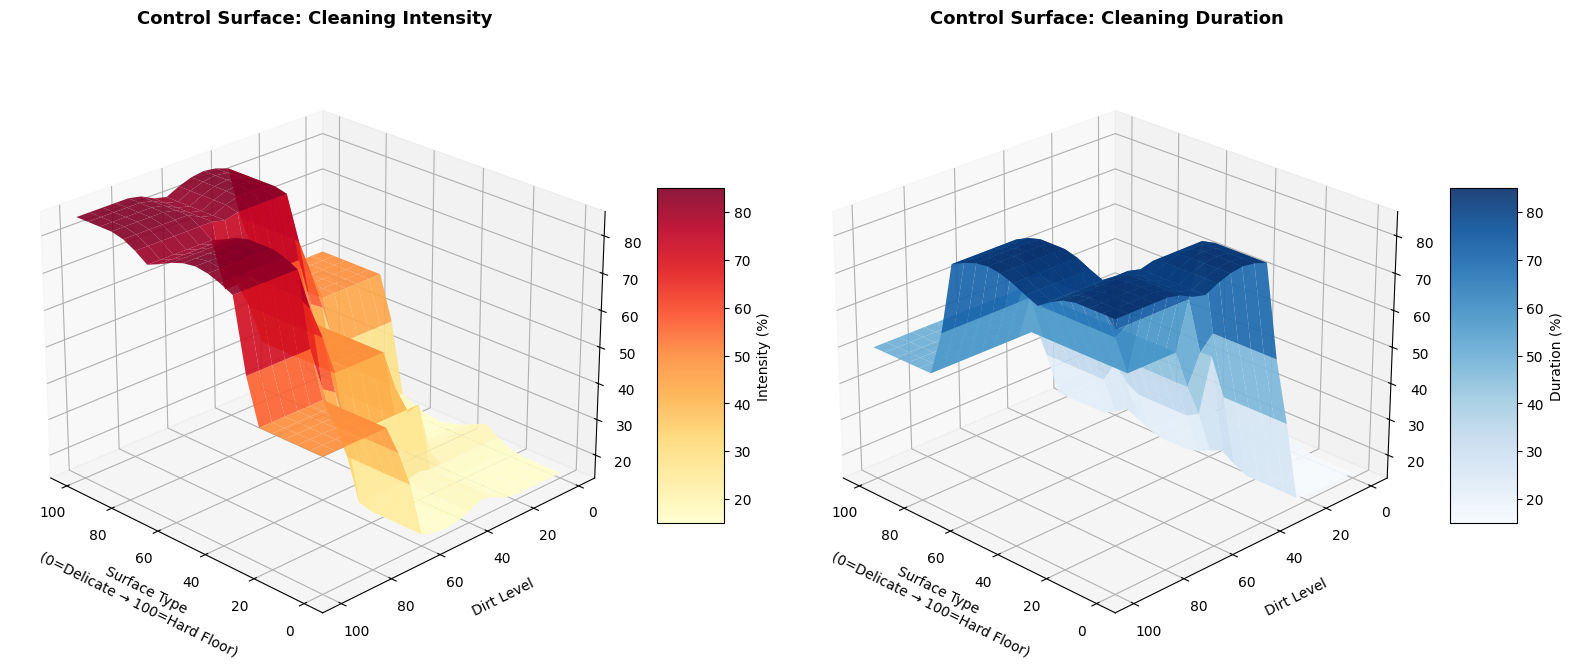

In [12]:
# 3D Surface Plots
from mpl_toolkits.mplot3d import Axes3D

X, Y = np.meshgrid(surface_range, dirt_range)

fig = plt.figure(figsize=(16, 7))

# Plot 1: Cleaning Intensity Surface
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X, Y, intensity_surface, cmap='YlOrRd', alpha=0.9, edgecolor='none')
ax1.set_xlabel('Surface Type\n(0=Delicate → 100=Hard Floor)', fontsize=10, labelpad=10)
ax1.set_ylabel('Dirt Level', fontsize=10, labelpad=10)
ax1.set_zlabel('Cleaning Intensity', fontsize=10, labelpad=10)
ax1.set_title('Control Surface: Cleaning Intensity', fontsize=13, fontweight='bold', pad=20)
ax1.view_init(elev=25, azim=135)
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5, label='Intensity (%)')

# Plot 2: Cleaning Duration Surface
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X, Y, duration_surface, cmap='Blues', alpha=0.9, edgecolor='none')
ax2.set_xlabel('Surface Type\n(0=Delicate → 100=Hard Floor)', fontsize=10, labelpad=10)
ax2.set_ylabel('Dirt Level', fontsize=10, labelpad=10)
ax2.set_zlabel('Cleaning Duration', fontsize=10, labelpad=10)
ax2.set_title('Control Surface: Cleaning Duration', fontsize=13, fontweight='bold', pad=20)
ax2.view_init(elev=25, azim=135)
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5, label='Duration (%)')

plt.tight_layout()
plt.show()

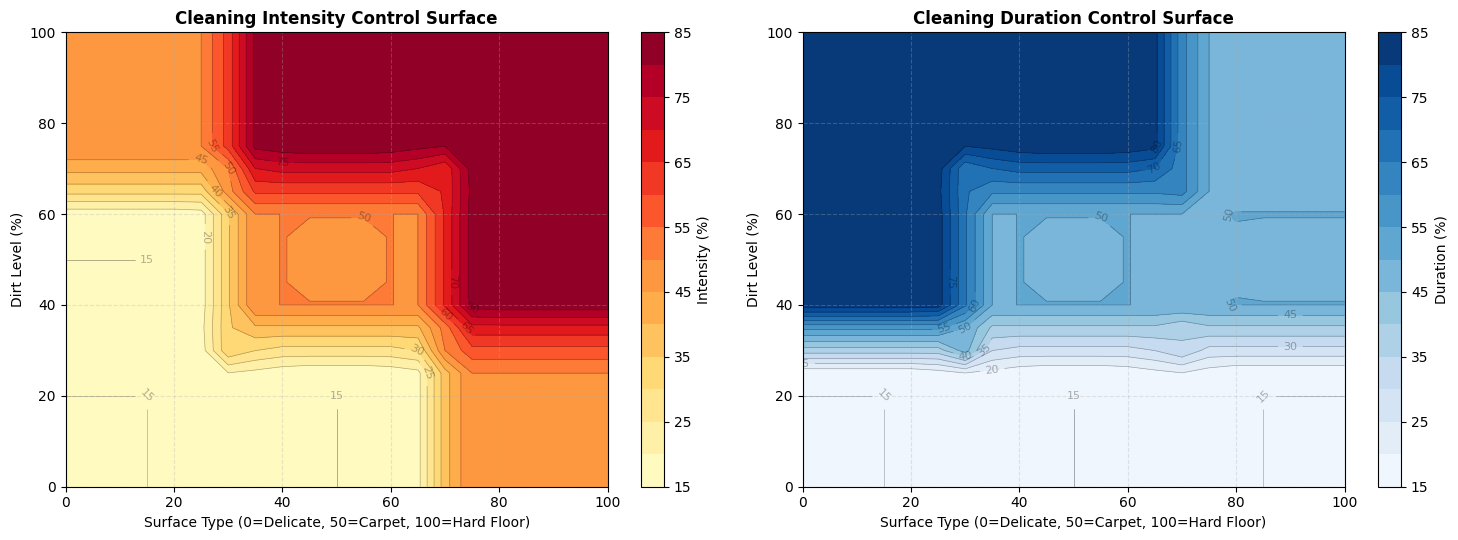

In [13]:
# 2D Contour plots for easier analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Contour 1: Intensity
levels_int = np.linspace(intensity_surface.min(), intensity_surface.max(), 15)
contour1 = ax1.contourf(X, Y, intensity_surface, levels=levels_int, cmap='YlOrRd')
contour1_lines = ax1.contour(X, Y, intensity_surface, levels=levels_int, colors='black', alpha=0.3, linewidths=0.5)
ax1.clabel(contour1_lines, inline=True, fontsize=8, fmt='%1.0f')
ax1.set_xlabel('Surface Type (0=Delicate, 50=Carpet, 100=Hard Floor)', fontsize=10)
ax1.set_ylabel('Dirt Level (%)', fontsize=10)
ax1.set_title('Cleaning Intensity Control Surface', fontsize=12, fontweight='bold')
fig.colorbar(contour1, ax=ax1, label='Intensity (%)')
ax1.grid(True, alpha=0.3, linestyle='--')

# Contour 2: Duration
levels_dur = np.linspace(duration_surface.min(), duration_surface.max(), 15)
contour2 = ax2.contourf(X, Y, duration_surface, levels=levels_dur, cmap='Blues')
contour2_lines = ax2.contour(X, Y, duration_surface, levels=levels_dur, colors='black', alpha=0.3, linewidths=0.5)
ax2.clabel(contour2_lines, inline=True, fontsize=8, fmt='%1.0f')
ax2.set_xlabel('Surface Type (0=Delicate, 50=Carpet, 100=Hard Floor)', fontsize=10)
ax2.set_ylabel('Dirt Level (%)', fontsize=10)
ax2.set_title('Cleaning Duration Control Surface', fontsize=12, fontweight='bold')
fig.colorbar(contour2, ax=ax2, label='Duration (%)')
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


### Answer: Activity 3 Control Surface Analysis

**1. Cleaning intensity versus dirt level.**
Intensity increases steadily as dirt increases, for every surface type. The surface climbs like a staircase with sloped steps: a low plateau (about 15 to 17%) for clean areas, a middle plateau (about 50%), and a high plateau (about 83 to 85%) for very dirty areas. The highest intensity is in the corner of high dirt and hard floor. Along the delicate edge the rise stops at about 50%, because the rules never allow aggressive cleaning on a delicate surface.

**2. Effect of surface type.**
1. Intensity: moving from delicate to hard floor raises intensity at every dirt level. Tougher surfaces can safely take stronger cleaning.
2. Duration: the effect is the opposite. At medium and high dirt, delicate surfaces get the longest duration (about 83 to 85%), while hard floors need only a standard duration (50%). At low dirt, every surface gets a quick clean (about 15%).
3. Together, the two surfaces are roughly mirror images. When the robot must be gentle it spends more time, and when it can be forceful it finishes faster.

**3. Smooth versus abrupt regions.**
The output is flat inside regions where one rule is fully active (for example dirt 0 to 20, where only "low" dirt applies). Between these plateaus the surface changes smoothly along sloped ramps. These ramps sit where membership functions overlap (dirt around 25 to 40 and 60 to 75, surface around 25 to 35 and 65 to 85). There are no vertical cliffs anywhere on the surface. This shows that a fuzzy system interpolates between its rules, so a small change in the input produces only a small change in the output. A crisp IF THEN controller would instead jump suddenly at its thresholds, and the robot would change behaviour abruptly.

## [Your after-class (additional) study]

A fuzzy inference system does not rely on rigid decision boundaries. Instead, it combines overlapping rules and membership functions to produce smooth and adaptive behaviour. This allows intelligent systems to operate effectively in environments where conditions are uncertain, imprecise, or continuously changing.

If you want to explore further:
* Try adding more inputs (battery level, time pressure)
* Experiment with different membership function shapes
